# Varer på salg 

Jeg har i denne oppgave besvarelsen laget et program som kan regne ut hvor lønnsomt det er for en bedrift å sette varer på salg. 

Videre informasjon angående hvordan, hvorfor og hvilke resultater koden produserte, står i rapporten vedlagt i besvarelsen.

Nedenfor finner du koden skrevet for å løse oppgaven

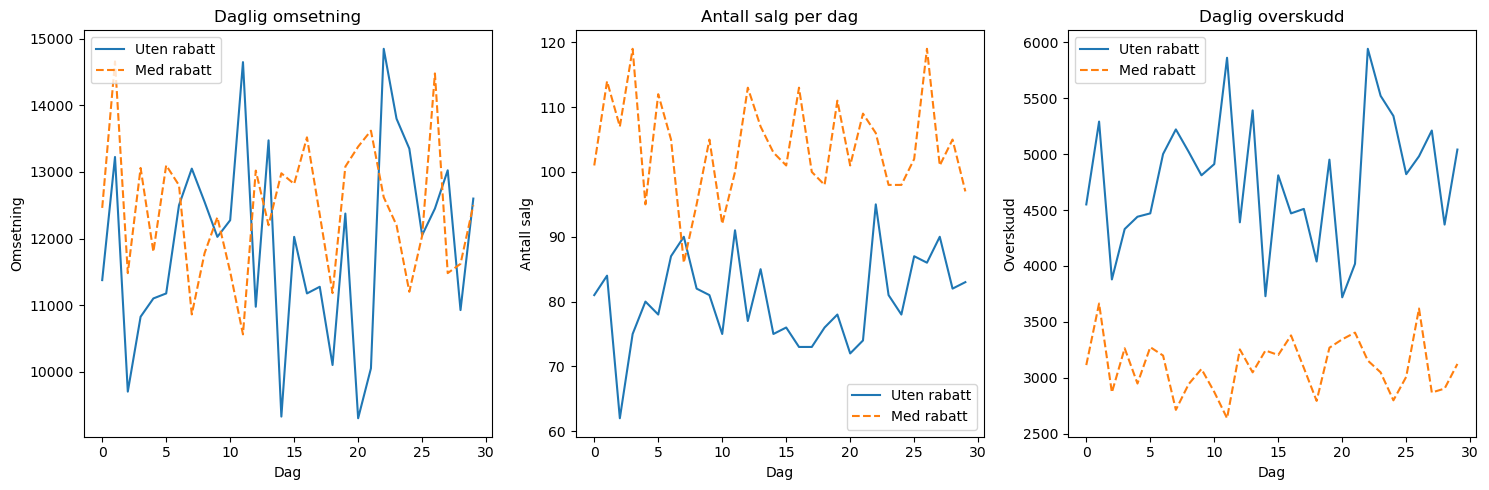

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Definer produktpriser (8 produkter)
produktpriser = np.array([100, 200, 150, 50, 75, 300, 250, 25])

# Antall kunder per dag
kunder_per_dag = 80

# Antall dager i en måned
dager = 30

# Dekningsgrad (andel av prisen som er overskudd)
dekningsgrad = 0.4  # 40% av salgsprisen er overskudd

# Innkjøpsprisen er resten av salgsprisen
innkjøpspriser = produktpriser * (1 - dekningsgrad)

# Definer sjanse for kjøp (uten rabatt)
kjøpssjanse = np.array([0.1, 0.15, 0.2, 0.05, 0.13, 0.07, 0.18, 0.12,])

# Rabattfaktor - juster denne for å se hvilken rabatt som maksimerer overskuddet
rabatt = 0.2  # 20% rabatt

# Når produktene er på salg, øker sjansen for kjøp, men prisen reduseres
kjøpssjanse_rabatt = kjøpssjanse * (1 + rabatt * 1.5)  # Økt sjanse for kjøp med rabatt

# Simuler kundens budsjett (normalfordeling)
def kundens_budsjett():
    return np.random.normal(800, 100)  # Gjennomsnittlig budsjett på 800 med avvik på 100

# Funksjon for å beregne overskudd
def beregn_overskudd(pris, innkjøpspris, rabattert=False):
    if rabattert:
        pris = pris * (1 - rabatt)  # Rabattert pris
    return pris - innkjøpspris

# Funksjon for å simulere en dag med eller uten rabatt
def simuler_dag(er_rabatt=False):
    total_omsetning = 0
    total_overskudd = 0
    total_salg = 0
    for kunde in range(kunder_per_dag):
        budsjett = kundens_budsjett()
        dagens_kjøpssjanse = kjøpssjanse_rabatt if er_rabatt else kjøpssjanse
        for i, pris in enumerate(produktpriser):
            if np.random.random() < dagens_kjøpssjanse[i] and budsjett >= pris * (1 - rabatt if er_rabatt else 1):
                faktisk_pris = pris * (1 - rabatt if er_rabatt else 1)
                total_omsetning += faktisk_pris
                total_salg += 1
                budsjett -= faktisk_pris  # Reduser budsjettet etter kjøp
                overskudd = beregn_overskudd(pris, innkjøpspriser[i], rabattert=er_rabatt)
                total_overskudd += overskudd
    return total_omsetning, total_salg, total_overskudd

# Simuler en måned (30 dager) med og uten rabatt
omsetning_uten_rabatt = []
salg_uten_rabatt = []
overskudd_uten_rabatt = []

omsetning_med_rabatt = []
salg_med_rabatt = []
overskudd_med_rabatt = []

for dag in range(dager):
    omsetning_ur, salg_ur, overskudd_ur = simuler_dag(er_rabatt=False)
    omsetning_uten_rabatt.append(omsetning_ur)
    salg_uten_rabatt.append(salg_ur)
    overskudd_uten_rabatt.append(overskudd_ur)
    
    omsetning_r, salg_r, overskudd_r = simuler_dag(er_rabatt=True)
    omsetning_med_rabatt.append(omsetning_r)
    salg_med_rabatt.append(salg_r)
    overskudd_med_rabatt.append(overskudd_r)

# Plot resultater
plt.figure(figsize=(15, 5))

# Plot for omsetning
plt.subplot(1, 3, 1)
plt.plot(omsetning_uten_rabatt, label="Uten rabatt")
plt.plot(omsetning_med_rabatt, label="Med rabatt", linestyle='--')
plt.xlabel("Dag")
plt.ylabel("Omsetning")
plt.title("Daglig omsetning")
plt.legend()

# Plot for antall salg
plt.subplot(1, 3, 2)
plt.plot(salg_uten_rabatt, label="Uten rabatt")
plt.plot(salg_med_rabatt, label="Med rabatt", linestyle='--')
plt.xlabel("Dag")
plt.ylabel("Antall salg")
plt.title("Antall salg per dag")
plt.legend()

# Plot for overskudd
plt.subplot(1, 3, 3)
plt.plot(overskudd_uten_rabatt, label="Uten rabatt")
plt.plot(overskudd_med_rabatt, label="Med rabatt", linestyle='--')
plt.xlabel("Dag")
plt.ylabel("Overskudd")
plt.title("Daglig overskudd")
plt.legend()

plt.tight_layout()
plt.show()